In [2]:
# # # To use the latest version of the sliderule client, run this cell.
# # # It will install the sliderule Python client into your current conda environment.
# # # You will then need to restart your kernel to have the changes take effect.
# %pip install --quiet "sliderule>=4.6"

In [1]:
from sliderule import sliderule, icesat2
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon, LineString, Point
from pyproj import Transformer
import xarray as xr
import rasterio
import ee
import geemap

import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
sliderule.init("slideruleearth.io");

In [3]:
region_f = "data/Glacier_polygons/Kangerlussuaq.geojson"

region = sliderule.toregion(region_f)
region['poly']

[{'lon': -32.89374989610119, 'lat': 68.54502859095385},
 {'lon': -32.744608039771265, 'lat': 68.57717274361003},
 {'lon': -32.79766190979542, 'lat': 68.62307988783661},
 {'lon': -33.012799007657854, 'lat': 68.69678989295065},
 {'lon': -33.03805798879968, 'lat': 68.69386006973387},
 {'lon': -33.12603439948326, 'lat': 68.63502805183425},
 {'lon': -33.08934994687182, 'lat': 68.61236517037554},
 {'lon': -33.01311409756367, 'lat': 68.58448190593616},
 {'lon': -32.89374989610119, 'lat': 68.54502859095385}]

In [4]:
# Specify the processing parameters
# parms = {
#     "poly": region["poly"],
#     "srt": icesat2.SRT_LAND,
#     "t0": datetime.date(2019, 1, 1).strftime('%Y-%m-%dT%H:%M:%SZ'),
#     "t1": datetime.date(2020, 6, 1).strftime('%Y-%m-%dT%H:%M:%SZ'),
#     "atl06_fields": ["dem/geoid_h"]
# }


# Specify the processing parameters
parms = {
    "poly": region["poly"],
    "srt": icesat2.SRT_LAND,
    "t0": datetime.date(2019, 6, 1).strftime('%Y-%m-%dT%H:%M:%SZ'),
    "t1": datetime.date(2021, 7, 1).strftime('%Y-%m-%dT%H:%M:%SZ'),
    "atl06_fields": ["dem/geoid_h"]
}

In [5]:
# (5) Make the processing request
gdf_IS2_ori = icesat2.atl06sp(parms)
gdf_IS2_ori = gdf_IS2_ori.dropna(subset=['h_li']) # remove points outside of the ATL06 land ice mask
gdf_IS2 = gdf_IS2_ori.to_crs(3413) # project to polar stereographic
gdf_IS2

,h_li,y_atc,rgt,w_surface_window_final,n_fit_photons,tide_ocean,seg_azimuth,sigma_geo_h,segment_id,h_li_sigma,...,r_eff,h_robust_sprd,cycle,atl06_quality_summary,dh_fit_dx,gt,bsnow_h,x_atc,geometry,dem/geoid_h
time,,,,,,,,,,,,,,,,,,,,,
2019-08-17 15:25:50.407744768,439.672729,-3196.092773,772,9.734441,87,NaN,-173.136826,5.352164,619811,0.212052,...,0.156452,0.958252,4,0,-0.381001,50,42.375427,1.241483e+07,POINT (490586.424 -2286310.912),54.475361
2019-08-17 15:25:50.410563840,432.216064,-3195.900635,772,7.003039,82,NaN,-173.136856,5.185364,619812,0.155487,...,0.151837,0.733609,4,0,-0.273597,50,42.366077,1.241485e+07,POINT (490588.212 -2286330.932),54.475395
2019-08-17 15:25:50.413383424,427.049194,-3196.113281,772,5.458086,81,NaN,-173.136887,5.113494,619813,0.140113,...,0.153261,0.632874,4,0,-0.212717,50,42.356728,1.241487e+07,POINT (490590.032 -2286350.948),54.475430
2019-08-17 15:25:50.416201984,422.543243,-3196.138916,772,6.808790,78,NaN,-173.136932,5.175408,619814,0.153972,...,0.144476,0.708948,4,0,-0.265950,50,42.347382,1.241489e+07,POINT (490591.865 -2286370.964),54.475468
2019-08-17 15:25:50.419018752,416.988617,-3196.317139,772,7.593387,66,NaN,-173.136963,5.217211,619815,0.230221,...,0.118311,0.902751,4,0,-0.296828,50,42.338039,1.241491e+07,POINT (490593.699 -2286390.98),54.475502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-05-21 20:02:28.393661184,567.891907,3218.813721,886,6.047663,100,NaN,-6.851004,1.017310,382071,0.177957,...,0.188489,1.007944,11,0,-0.011623,20,NaN,7.658073e+06,POINT (489404.301 -2285657.227),54.463753
2021-05-21 20:02:28.396484352,567.870605,3218.778809,886,6.702317,126,NaN,-6.851038,0.902056,382072,0.152603,...,0.239874,1.117053,11,0,-0.017470,20,NaN,7.658093e+06,POINT (489397.772 -2285638.215),54.463608
2021-05-21 20:02:28.399309056,567.413635,3218.759033,886,5.001027,162,NaN,-6.851070,0.640712,382073,0.137390,...,0.320930,0.833504,11,0,-0.025021,20,NaN,7.658113e+06,POINT (489391.247 -2285619.202),54.463455


In [6]:
## Read in bedmachine data

Bed_ele_f = "data/BedMachine/BedMachineGreenland-v5.nc"
Bed_ele = xr.open_dataset(Bed_ele_f)
Bed_ele

<xarray.Dataset> Size: 4GB
Dimensions:    (x: 10218, y: 18346)
Coordinates:
  * x          (x) int32 41kB -652925 -652775 -652625 ... 879325 879475 879625
  * y          (y) int32 73kB -632675 -632825 -632975 ... -3384275 -3384425
Data variables:
    mapping    |S1 1B ...
    mask       (y, x) int8 187MB ...
    surface    (y, x) float32 750MB ...
    thickness  (y, x) float32 750MB ...
    bed        (y, x) float32 750MB ...
    errbed     (y, x) float32 750MB ...
    source     (y, x) int8 187MB ...
    dataid     (y, x) int8 187MB ...
    geoid      (y, x) int16 375MB ...
Attributes: (12/16)
    Conventions:                 CF-1.7
    Title:                       BedMachine Greenland
    Author:                      Mathieu Morlighem
    version:                     28-Jul-2022 (v5.5)
    nx:                          10218.0
    ny:                          18346.0
    ...                          ...
    xmin:                        -652925
    ymax:                        -632675
    spacing:                     150
    no_data:                     -9999.0
    license:                     No restrictions on access or use
    Data_citation:               Morlighem M. et al., (2017), BedMachine v3: ...

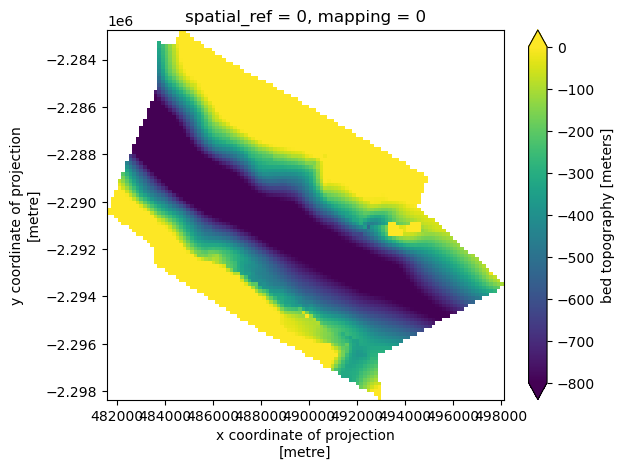

In [7]:
# Add projection info to the "bed" variable (probably don't need this step using rioxarray)
bed_projected = Bed_ele.bed.rio.write_crs(3413, inplace=True).rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True).rio.write_coordinate_system(inplace=True).to_dataset()

# Read region polygon using geopandas
region_gdf = gpd.read_file(region_f)

# Subset netcdf raster with region polygon
bed_subset = bed_projected.rio.clip(region_gdf.geometry.values, region_gdf.crs, drop=True)

# Plot
bed_subset["bed"].plot(vmin = -800, vmax = 0)

In [8]:
## Profiling BedMachine at the location of ICESat-2 data

x = xr.DataArray(gdf_IS2["geometry"].values.x, dims="points")
y = xr.DataArray(gdf_IS2["geometry"].values.y, dims="points")

bed_profile = bed_subset.sel(x=x, y=y, method='nearest')
bed_profile_arr = bed_profile["bed"].values

gdf_IS2["bed_ele"] = bed_profile_arr

In [9]:

# Only keep rows where the bedrock is beneath sea-level
gdf_bsl = gdf_IS2[gdf_IS2["bed_ele"]<0]

# Floation height
fh = np.abs(gdf_bsl["bed_ele"]*108/917)
gdf_bsl["floatation_height"] = fh


# Grounded mask
thre = 0 # meters, threshold or a vertical buffer to get the grounding line

# if surface height is higher than the floatation height by thre, define it as grounded
diff_fh = gdf_bsl["h_li"] - gdf_bsl["dem/geoid_h"] - gdf_bsl["floatation_height"]
mask_grounded = diff_fh > thre 

gdf_bsl["diff_fh"] = diff_fh
gdf_bsl["mask_grounded"] = mask_grounded

gdf_bsl.head()


/srv/conda/envs/notebook/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/srv/conda/envs/notebook/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/srv/conda/envs/notebook/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

,h_li,y_atc,rgt,w_surface_window_final,n_fit_photons,tide_ocean,seg_azimuth,sigma_geo_h,segment_id,h_li_sigma,...,dh_fit_dx,gt,bsnow_h,x_atc,geometry,dem/geoid_h,bed_ele,floatation_height,diff_fh,mask_grounded
time,,,,,,,,,,,,,,,,,,,,,
2019-08-17 15:25:50.647292928,154.831573,-3194.459961,772,3.000000,63,NaN,-173.139618,0.159802,619896,0.061880,...,-0.017019,50,41.581017,1.241654e+07,POINT (490744.663 -2288012.059),54.478794,-18.225967,2.146570,98.206215,True
2019-08-17 15:25:50.650129920,154.411057,-3194.447266,772,3.778996,69,NaN,-173.139664,0.180332,619897,0.081423,...,-0.024648,50,41.571609,1.241656e+07,POINT (490746.553 -2288032.071),54.478840,-18.225967,2.146570,97.785652,True
2019-08-17 15:25:50.652964608,154.150208,-3194.519043,772,3.863101,63,NaN,-173.139694,0.154535,619898,0.104314,...,-0.005693,50,41.562206,1.241658e+07,POINT (490748.433 -2288052.083),54.478889,-18.225967,2.146570,97.524750,True
2019-08-17 15:25:50.793729280,112.898788,-3194.251221,772,5.586372,82,NaN,-173.141327,0.308492,619948,0.219960,...,0.006056,50,41.095390,1.241758e+07,POINT (490841.534 -2289052.798),54.481621,-7.917542,0.932491,57.484676,True
2019-08-17 15:25:50.796546304,112.224358,-3194.343262,772,6.741786,118,NaN,-173.141357,0.548293,619949,0.173915,...,-0.074987,50,41.086048,1.241760e+07,POINT (490843.372 -2289072.815),54.481689,-7.917542,0.932491,56.810177,True


In [10]:
# ## Validation dataset
# GL_Ciraci2023_f = "data/GL_Ciraci2023/petermann_grounding_lines_1992-2022.shp"
# GL_Ciraci2023 = gpd.read_file(GL_Ciraci2023_f)

# time_dt = []
# for time_str in GL_Ciraci2023["time"].values:
#     time_dt.append(datetime.datetime.strptime(time_str, '%Y-%m-%d').date())
# GL_Ciraci2023["date"] = np.asarray(time_dt)

In [11]:
## Validation dataset
tp_0788_f = "data/Terminus_change/NSIDC-0788_termTS_GID152_1972_2022_V01.0.shp" # terminus position of Kangerlussuaq from Autoterm
tp_0788 = gpd.read_file(tp_0788_f)
tp_0788 = tp_0788.to_crs(3413)

time_dt = []
for time_str in tp_0788["Date"].values:
    time_dt.append(time_str.astype(datetime.datetime).date())
tp_0788["date"] = np.asarray(time_dt)

In [12]:
line_show = tp_0788.copy()


/tmp/ipykernel_18529/378693674.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


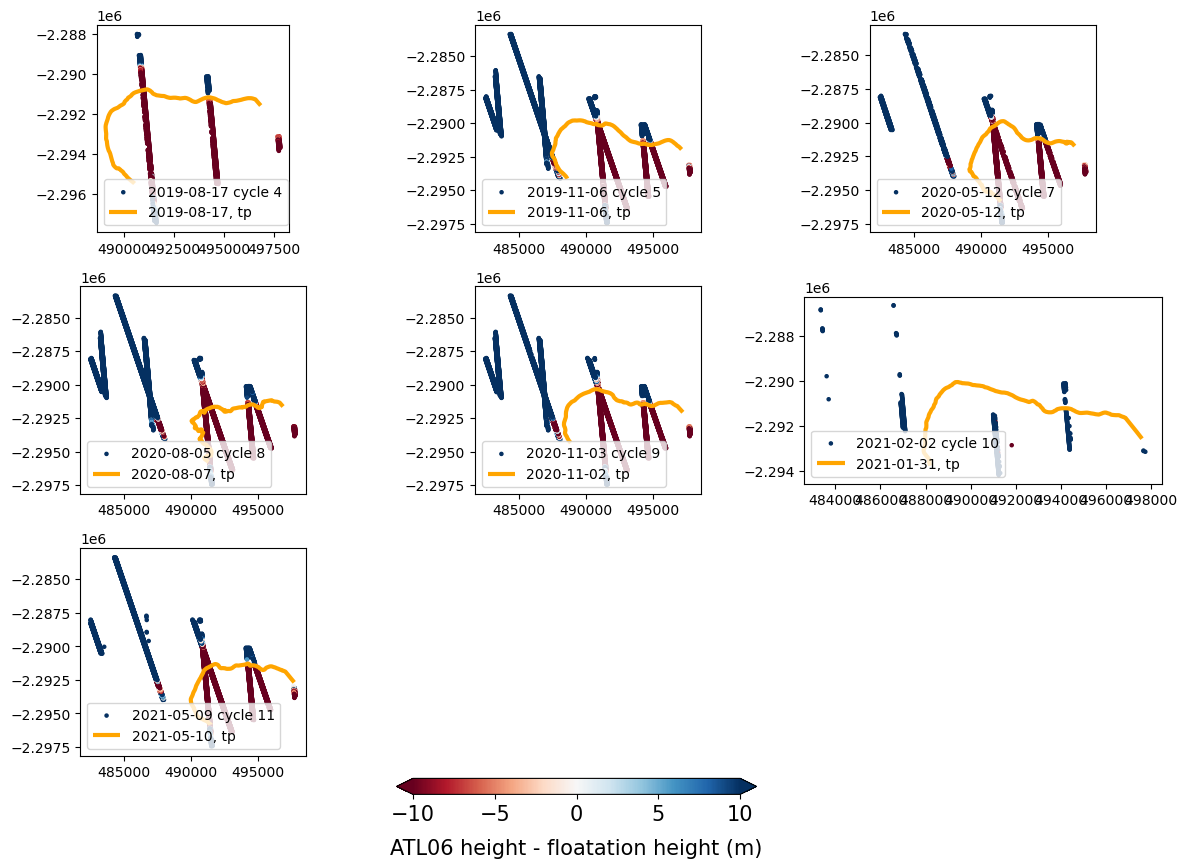

In [13]:
%matplotlib inline

## grounded vs. floating in each cycle from ATL06

cycles = np.unique(gdf_bsl["cycle"].values)

fig, ax = plt.subplots(int(np.ceil(len(cycles)/3)), 3, figsize = (12, 8))
axs = ax.ravel()

# dates_cycle_l = []
id_nearest_l = []
for i, cycle in enumerate(cycles):
    gdf_cycle = gdf_bsl[gdf_bsl["cycle"] == cycle]
    dates_cycle = gdf_cycle.index.mean().date()
    # dates_cycle_l.append(dates_cycle)
    dates_cycle_str = dates_cycle.strftime('%Y-%m-%d')

    id_nearest = np.argmin(np.abs(line_show["date"].values - dates_cycle))
    id_nearest_l.append(id_nearest_l)
    line_show_nearest = line_show[line_show.index == id_nearest]
    

    im = axs[i].scatter(gdf_cycle["geometry"].values.x, gdf_cycle["geometry"].values.y, c = gdf_cycle["diff_fh"].values, cmap='RdBu', 
                   vmin = -10, vmax = 10, marker="o", s = 5, label = dates_cycle_str+" cycle "+str(cycle))
    
    line_show_nearest.plot(ax=axs[i], color = "orange", linewidth = 3, label = str(line_show_nearest["date"].item())+", tp")
      
    axs[i].set_aspect('equal')
    axs[i].legend(loc = 3, fontsize = 10)

cbar_ax = fig.add_axes([0.35, 0., 0.3, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, shrink=0.5, extend='both', orientation = "horizontal")
cbar.ax.tick_params(labelsize=15) 
cbar.set_label("ATL06 height - floatation height (m)", rotation=0, fontsize=15, labelpad = 10)


for c, ax in enumerate(axs):
    if c > i:
        ax.axis('off')

fig.tight_layout()

plt.show()


# fig.savefig('figures/Kangerlussuaq_CE_floatation_height.jpg',
#         format='jpeg',
#         dpi=200,
#         bbox_inches='tight')


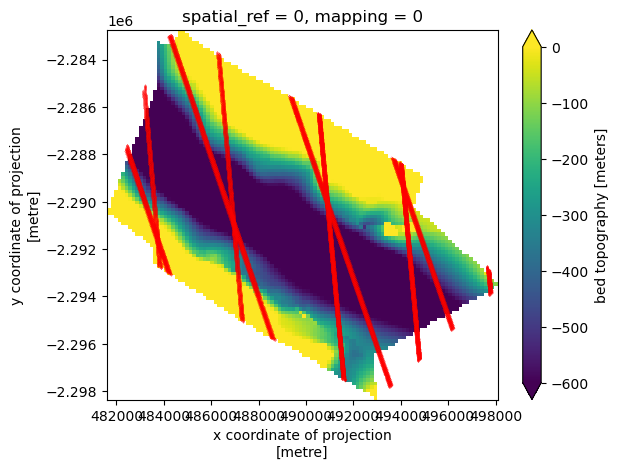

In [177]:
fig, ax = plt.subplots()
bed_subset["bed"].plot(vmin = -600, vmax = 0, ax = ax)
ax.scatter(gdf_IS2["geometry"].values.x, gdf_IS2["geometry"].values.y, c = "red", s = 0.01)
ax.set_aspect('equal')
plt.show()